# 08 — Baseline Multiclass DL (MLP + 1D CNN)

**Goal:** Train MLP and 1D CNN on the balanced 8-category training set.  
Evaluate on the original imbalanced validation and test sets.  
Report per-class precision, recall, F1 for all 8 categories.

**Runtime:** Colab Pro — A100 GPU + High-RAM

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import json, time, os, warnings, gc
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
GPU: Tesla T4
PyTorch: 2.10.0+cu128


In [5]:
DRIVE_PATH   = '/content/drive/MyDrive/CICIoT2023_Research'
RESULTS_PATH = f'{DRIVE_PATH}/results'
os.makedirs(RESULTS_PATH, exist_ok=True)

ATTACK_TAXONOMY = {
    'DDoS':       ['DDOS-ICMP_FLOOD','DDOS-UDP_FLOOD','DDOS-TCP_FLOOD','DDOS-PSHACK_FLOOD',
                   'DDOS-SYN_FLOOD','DDOS-RSTFINFLOOD','DDOS-SYNONYMOUSIP_FLOOD',
                   'DDOS-ACK_FRAGMENTATION','DDOS-UDP_FRAGMENTATION','DDOS-ICMP_FRAGMENTATION',
                   'DDOS-SLOWLORIS','DDOS-HTTP_FLOOD'],
    'DoS':        ['DOS-UDP_FLOOD','DOS-TCP_FLOOD','DOS-SYN_FLOOD','DOS-HTTP_FLOOD'],
    'Mirai':      ['MIRAI-GREETH_FLOOD','MIRAI-UDPPLAIN','MIRAI-GREIP_FLOOD'],
    'Recon':      ['RECON-HOSTDISCOVERY','RECON-OSSCAN','RECON-PORTSCAN',
                   'RECON-PINGSWEEP','VULNERABILITYSCAN'],
    'Spoofing':   ['MITM-ARPSPOOFING','DNS_SPOOFING'],
    'Web':        ['XSS','COMMANDINJECTION','BACKDOOR_MALWARE','SQLINJECTION',
                   'UPLOADING_ATTACK','BROWSERHIJACKING'],
    'BruteForce': ['DICTIONARYBRUTEFORCE'],
    'Benign':     ['BENIGN']
}

CATEGORY_ENCODING = {cat: i for i, cat in enumerate(ATTACK_TAXONOMY.keys())}
CATEGORY_NAMES    = {v: k for k, v in CATEGORY_ENCODING.items()}
LABEL_TO_CATEGORY = {
    label: cat
    for cat, labels in ATTACK_TAXONOMY.items()
    for label in labels
}

print('Category encoding:')
for cat, idx in CATEGORY_ENCODING.items():
    print(f'  {idx}: {cat}')

Category encoding:
  0: DDoS
  1: DoS
  2: Mirai
  3: Recon
  4: Spoofing
  5: Web
  6: BruteForce
  7: Benign


In [6]:
with open(f'{DRIVE_PATH}/label_mapping.json') as f:
    label_mapping = json.load(f)

INT_TO_LABEL = {v: k for k, v in label_mapping.items()}

def map_fine_to_category(y_fine):
    return y_fine.map(
        lambda x: CATEGORY_ENCODING[LABEL_TO_CATEGORY[INT_TO_LABEL[x]]]
    )

print(f'Label mapping loaded — {len(label_mapping)} fine-grained classes.')

Label mapping loaded — 34 fine-grained classes.


In [7]:
print('Loading X_val for feature names...')
t0 = time.time()
X_val = pd.read_csv(f'{DRIVE_PATH}/X_val.csv')
FEATURE_NAMES = X_val.columns.tolist()
print(f'X_val: {X_val.shape}  ({time.time()-t0:.1f}s)')

print('Loading balanced training data...')
t0 = time.time()
X_train = pd.read_csv(f'{DRIVE_PATH}/X_train_balanced_8cat_smoteenn.csv')
X_train.columns = FEATURE_NAMES
y_train = pd.read_csv(
    f'{DRIVE_PATH}/y_train_balanced_8cat_smoteenn.csv', header=0
).squeeze()
print(f'X_train: {X_train.shape}  ({time.time()-t0:.1f}s)')

print('Loading val labels...')
y_val_fine = pd.read_csv(
    f'{DRIVE_PATH}/y_val_multi.csv', header=0, dtype=int
).squeeze()
y_val = map_fine_to_category(y_val_fine)

print('Loading test data...')
t0 = time.time()
X_test = pd.read_csv(f'{DRIVE_PATH}/X_test.csv')
y_test_fine = pd.read_csv(
    f'{DRIVE_PATH}/y_test_multi.csv', header=0, dtype=int
).squeeze()
y_test = map_fine_to_category(y_test_fine)
print(f'X_test: {X_test.shape}  ({time.time()-t0:.1f}s)')

print(f'\nAll loaded.')
print(f'  Train: {len(X_train):,} (balanced)')
print(f'  Val:   {len(X_val):,} (imbalanced)')
print(f'  Test:  {len(X_test):,} (imbalanced)')

Loading X_val for feature names...
X_val: (2100516, 39)  (12.4s)
Loading balanced training data...
X_train: (1629654, 39)  (10.5s)
Loading val labels...
Loading test data...
X_test: (4201031, 39)  (27.3s)

All loaded.
  Train: 1,629,654 (balanced)
  Val:   2,100,516 (imbalanced)
  Test:  4,201,031 (imbalanced)


In [8]:
# Convert to tensors and move to GPU
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)

X_val_t   = torch.tensor(X_val.values,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val.values,   dtype=torch.long)

X_test_t  = torch.tensor(X_test.values,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.long)

# Free pandas dataframes — no longer needed
del X_train, X_val, X_test
del y_train, y_val, y_test
del y_val_fine, y_test_fine
gc.collect()

# DataLoaders — batch training for GPU efficiency
BATCH_SIZE = 2048   # Large batch fits easily in 80GB A100

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE, shuffle=False
)

print(f'Tensors created.')
print(f'  X_train_t: {X_train_t.shape}')
print(f'  X_val_t:   {X_val_t.shape}')
print(f'  X_test_t:  {X_test_t.shape}')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  Train batches per epoch: {len(train_loader)}')

Tensors created.
  X_train_t: torch.Size([1629654, 39])
  X_val_t:   torch.Size([2100516, 39])
  X_test_t:  torch.Size([4201031, 39])
  Batch size: 2048
  Train batches per epoch: 796


In [9]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            preds = model(X_batch.to(device)).argmax(dim=1)
            all_preds.append(preds.cpu())
    return torch.cat(all_preds).numpy()


def get_true_labels(loader):
    return torch.cat([y for _, y in loader]).numpy()


def print_results(model_name, split_name, y_true, y_pred):
    acc    = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1_wt  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    target_names = [CATEGORY_NAMES[i] for i in sorted(CATEGORY_NAMES)]
    print(f'\n{"="*60}')
    print(f'{model_name} — {split_name}')
    print(f'{"="*60}')
    print(f'  Accuracy:      {acc:.4f}')
    print(f'  F1 (macro):    {f1_mac:.4f}')
    print(f'  F1 (weighted): {f1_wt:.4f}')
    print()
    print(classification_report(y_true, y_pred,
                                target_names=target_names, zero_division=0))
    return acc, f1_mac, f1_wt


def plot_confusion_matrix(y_true, y_pred, model_name, save_path=None):
    labels = [CATEGORY_NAMES[i] for i in sorted(CATEGORY_NAMES)]
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                vmin=0, vmax=1, ax=ax, linewidths=0.5)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(f'{model_name} — Confusion Matrix (Normalized)\nTest Set (Imbalanced)', fontsize=13)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


def training_loop(model, model_name, epochs=30, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    best_val_f1  = 0.0
    best_weights = None
    history      = {'train_loss': [], 'val_f1': []}
    y_val_true   = get_true_labels(val_loader)

    print(f'\nTraining {model_name} for {epochs} epochs...')
    print(f'{"Epoch":>6} {"Train Loss":>12} {"Val F1 Mac":>12} {"Time":>8}')
    print('-' * 42)

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss = train_epoch(model, train_loader, criterion, optimizer)
        val_preds  = evaluate(model, val_loader)
        val_f1     = f1_score(y_val_true, val_preds,
                              average='macro', zero_division=0)
        scheduler.step(val_f1)
        history['train_loss'].append(train_loss)
        history['val_f1'].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1  = val_f1
            best_weights = {k: v.cpu().clone()
                            for k, v in model.state_dict().items()}
            flag = ' ← best'
        else:
            flag = ''

        print(f'{epoch:>6} {train_loss:>12.4f} {val_f1:>12.4f} '
              f'{time.time()-t0:>7.1f}s{flag}')

    model.load_state_dict(best_weights)
    print(f'\nBest val F1 macro: {best_val_f1:.4f}')
    return model, history


print('Helper functions defined.')

Helper functions defined.


In [10]:
class MLP(nn.Module):
    """
    Multi-Layer Perceptron.
    Input: 39 features
    Hidden: 256 → 128 → 64
    Output: 8 classes
    BatchNorm + Dropout after each hidden layer.
    """
    def __init__(self, input_dim=39, num_classes=8, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(input_dim),

            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)


class CNN1D(nn.Module):
    """
    1D Convolutional Neural Network.
    Treats the 39 features as a 1D sequence of length 39.
    Conv layers extract local feature patterns,
    then a small MLP head classifies.
    Input shape: (batch, 39) → reshaped to (batch, 1, 39)
    """
    def __init__(self, input_dim=39, num_classes=8, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            # Conv block 1
            nn.Conv1d(in_channels=1, out_channels=64,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),

            # Conv block 2
            nn.Conv1d(in_channels=64, out_channels=128,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1)   # Global average pooling → (batch, 128, 1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),             # (batch, 128)
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)           # (batch, 39) → (batch, 1, 39)
        x = self.conv(x)
        return self.classifier(x)


# Quick parameter count
mlp  = MLP()
cnn  = CNN1D()

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'MLP     parameters: {count_params(mlp):,}')
print(f'1D CNN  parameters: {count_params(cnn):,}')

MLP     parameters: 52,886
1D CNN  parameters: 34,120


In [11]:
mlp, mlp_history = training_loop(
    model=MLP(),
    model_name='MLP',
    epochs=30,
    lr=0.001
)


Training MLP for 30 epochs...
 Epoch   Train Loss   Val F1 Mac     Time
------------------------------------------
     1       0.2792       0.5920    38.7s ← best
     2       0.1948       0.6105    37.9s ← best
     3       0.1801       0.6066    37.4s
     4       0.1730       0.6115    36.9s ← best
     5       0.1682       0.6120    37.8s ← best
     6       0.1651       0.6053    38.5s
     7       0.1621       0.6088    38.2s
     8       0.1604       0.6086    37.9s
     9       0.1585       0.6118    38.1s
    10       0.1535       0.6113    38.1s
    11       0.1519       0.6171    38.2s ← best
    12       0.1509       0.6156    38.3s
    13       0.1500       0.6140    38.6s
    14       0.1487       0.6191    38.4s ← best
    15       0.1480       0.6203    38.4s ← best
    16       0.1476       0.6207    38.1s ← best
    17       0.1470       0.6200    37.9s
    18       0.1465       0.6225    37.8s ← best
    19       0.1462       0.6217    38.0s
    20       0.1456    

In [12]:
y_val_true  = get_true_labels(val_loader)
y_test_true = get_true_labels(test_loader)

print('=== MLP VALIDATION ===')
mlp_val_acc, mlp_val_f1mac, mlp_val_f1wt = print_results(
    'MLP', 'Validation', y_val_true, evaluate(mlp, val_loader)
)

print('=== MLP TEST (Imbalanced) ===')
mlp_test_preds = evaluate(mlp, test_loader)
mlp_test_acc, mlp_test_f1mac, mlp_test_f1wt = print_results(
    'MLP', 'Test (Imbalanced)', y_test_true, mlp_test_preds
)

=== MLP VALIDATION ===

MLP — Validation
  Accuracy:      0.7863
  F1 (macro):    0.6290
  F1 (weighted): 0.8000

              precision    recall  f1-score   support

        DDoS       0.93      0.74      0.83   1228858
         DoS       0.53      0.83      0.64    417978
       Mirai       0.99      1.00      1.00    235768
       Recon       0.86      0.53      0.65     65758
    Spoofing       0.89      0.68      0.77     43696
         Web       0.06      0.58      0.10      2490
  BruteForce       0.15      0.46      0.23      1237
      Benign       0.78      0.85      0.81    104731

    accuracy                           0.79   2100516
   macro avg       0.65      0.71      0.63   2100516
weighted avg       0.84      0.79      0.80   2100516

=== MLP TEST (Imbalanced) ===

MLP — Test (Imbalanced)
  Accuracy:      0.7863
  F1 (macro):    0.6274
  F1 (weighted): 0.8001

              precision    recall  f1-score   support

        DDoS       0.93      0.74      0.83   245820

Saved: /content/drive/MyDrive/CICIoT2023_Research/results/mlp_confusion_matrix_test.png


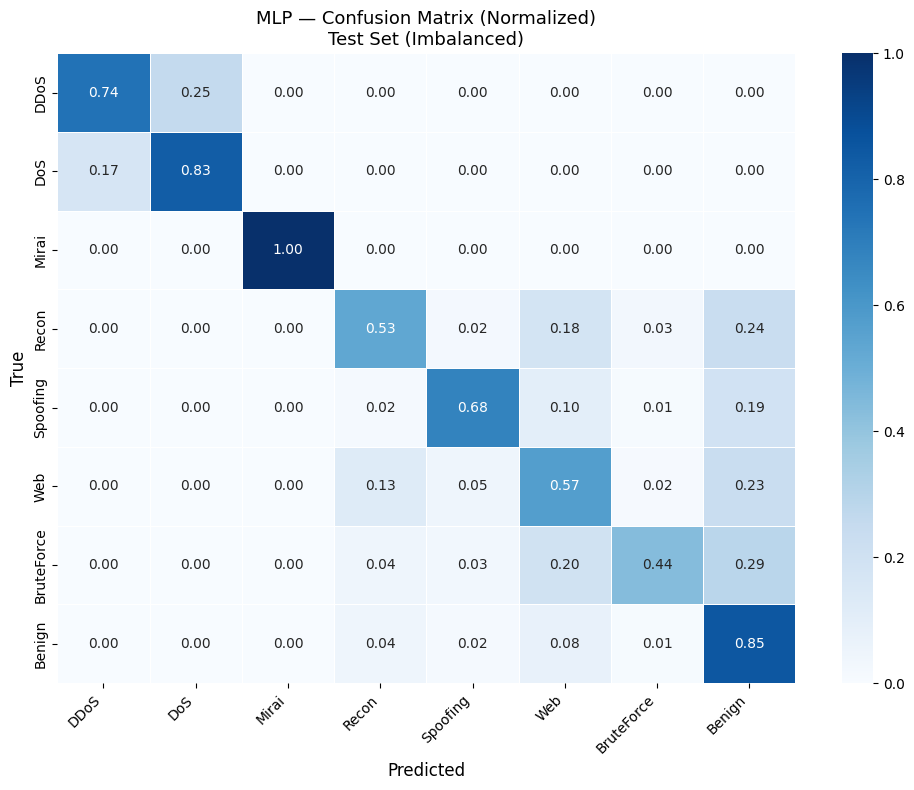

MLP model saved.


In [13]:
plot_confusion_matrix(
    y_test_true, mlp_test_preds, 'MLP',
    save_path=f'{RESULTS_PATH}/mlp_confusion_matrix_test.png'
)

torch.save(mlp.state_dict(), f'{DRIVE_PATH}/mlp_model_8cat_baseline.pt')
print('MLP model saved.')

In [14]:
cnn, cnn_history = training_loop(
    model=CNN1D(),
    model_name='1D CNN',
    epochs=30,
    lr=0.001
)


Training 1D CNN for 30 epochs...
 Epoch   Train Loss   Val F1 Mac     Time
------------------------------------------
     1       0.4374       0.5707    48.3s ← best
     2       0.2642       0.6026    47.4s ← best
     3       0.2382       0.5621    47.5s
     4       0.2222       0.5788    47.0s
     5       0.2065       0.5958    47.5s
     6       0.1970       0.6105    47.9s ← best
     7       0.1907       0.6166    47.7s ← best
     8       0.1861       0.5953    46.9s
     9       0.1797       0.6167    46.3s ← best
    10       0.1745       0.6381    46.2s ← best
    11       0.1704       0.6392    46.9s ← best
    12       0.1663       0.6224    47.6s
    13       0.1640       0.6283    46.1s
    14       0.1611       0.6337    45.5s
    15       0.1589       0.6354    45.4s
    16       0.1526       0.6268    45.4s
    17       0.1512       0.6254    45.3s
    18       0.1503       0.6448    45.0s ← best
    19       0.1491       0.5793    45.1s
    20       0.1490       0

In [15]:
print('=== 1D CNN VALIDATION ===')
cnn_val_acc, cnn_val_f1mac, cnn_val_f1wt = print_results(
    '1D CNN', 'Validation', y_val_true, evaluate(cnn, val_loader)
)

print('=== 1D CNN TEST (Imbalanced) ===')
cnn_test_preds = evaluate(cnn, test_loader)
cnn_test_acc, cnn_test_f1mac, cnn_test_f1wt = print_results(
    '1D CNN', 'Test (Imbalanced)', y_test_true, cnn_test_preds
)

=== 1D CNN VALIDATION ===

1D CNN — Validation
  Accuracy:      0.7871
  F1 (macro):    0.6506
  F1 (weighted): 0.7979

              precision    recall  f1-score   support

        DDoS       0.93      0.74      0.82   1228858
         DoS       0.52      0.83      0.64    417978
       Mirai       0.99      1.00      0.99    235768
       Recon       0.83      0.56      0.66     65758
    Spoofing       0.89      0.73      0.80     43696
         Web       0.10      0.31      0.15      2490
  BruteForce       0.31      0.33      0.32      1237
      Benign       0.73      0.90      0.81    104731

    accuracy                           0.79   2100516
   macro avg       0.66      0.67      0.65   2100516
weighted avg       0.84      0.79      0.80   2100516

=== 1D CNN TEST (Imbalanced) ===

1D CNN — Test (Imbalanced)
  Accuracy:      0.7871
  F1 (macro):    0.6473
  F1 (weighted): 0.7979

              precision    recall  f1-score   support

        DDoS       0.93      0.74      0

Saved: /content/drive/MyDrive/CICIoT2023_Research/results/cnn_confusion_matrix_test.png


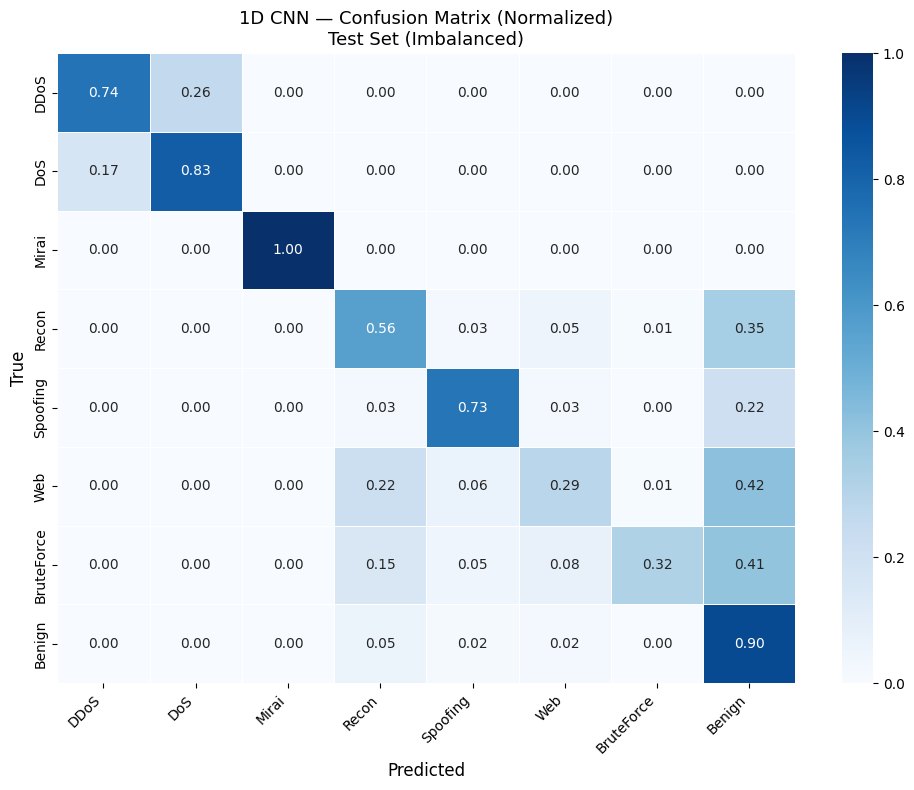

1D CNN model saved.


In [16]:
plot_confusion_matrix(
    y_test_true, cnn_test_preds, '1D CNN',
    save_path=f'{RESULTS_PATH}/cnn_confusion_matrix_test.png'
)

torch.save(cnn.state_dict(), f'{DRIVE_PATH}/cnn_model_8cat_baseline.pt')
print('1D CNN model saved.')

Saved: /content/drive/MyDrive/CICIoT2023_Research/results/dl_training_curves.png


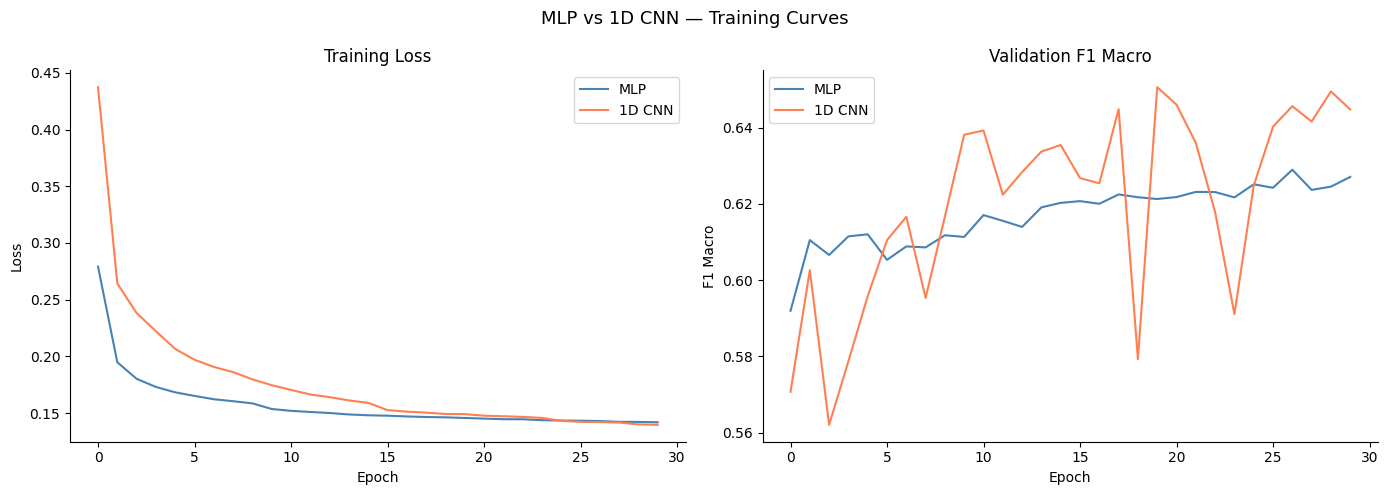

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mlp_history['train_loss'], label='MLP', color='steelblue')
axes[0].plot(cnn_history['train_loss'], label='1D CNN', color='coral')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(mlp_history['val_f1'], label='MLP', color='steelblue')
axes[1].plot(cnn_history['val_f1'], label='1D CNN', color='coral')
axes[1].set_title('Validation F1 Macro')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Macro')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('MLP vs 1D CNN — Training Curves', fontsize=13)
plt.tight_layout()
save_path = f'{RESULTS_PATH}/dl_training_curves.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()


FINAL RESULTS — TEST SET (IMBALANCED)
                        MLP     1D CNN
--------------------------------------
Accuracy             0.7863     0.7871
F1 macro             0.6274     0.6473
F1 weighted          0.8001     0.7979
Saved: /content/drive/MyDrive/CICIoT2023_Research/results/dl_baseline_f1_comparison.png


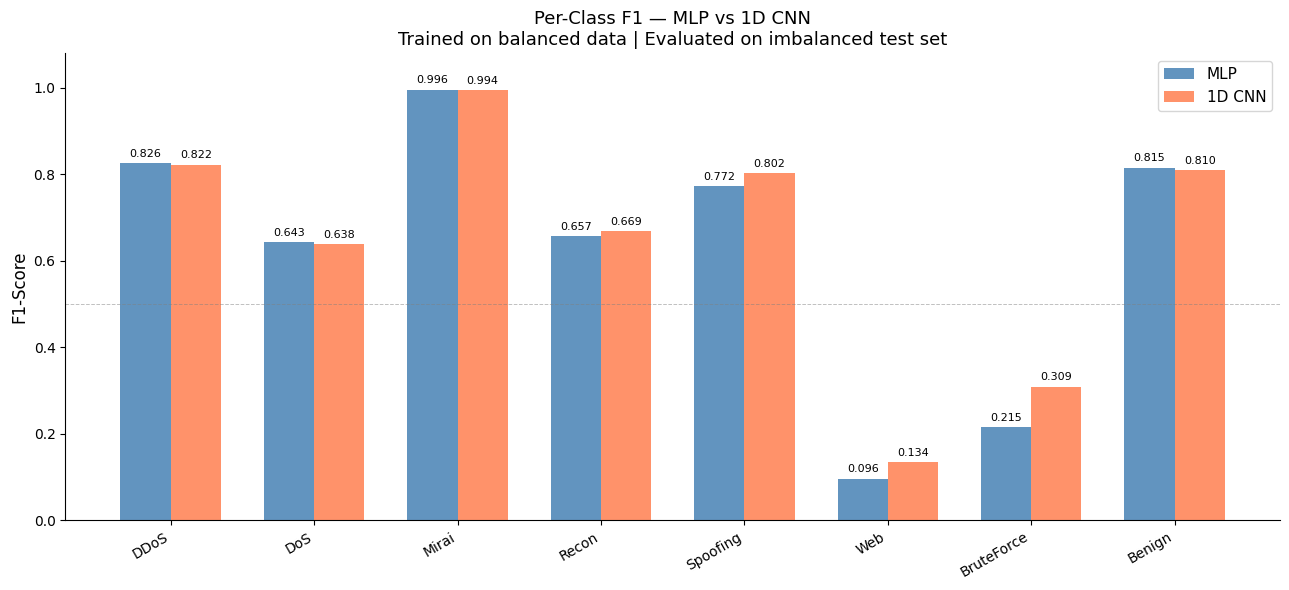

In [18]:
# Summary table
print('\n' + '='*70)
print('FINAL RESULTS — TEST SET (IMBALANCED)')
print('='*70)
print(f'{"":16} {"MLP":>10} {"1D CNN":>10}')
print('-'*38)
print(f'{"Accuracy":<16} {mlp_test_acc:>10.4f} {cnn_test_acc:>10.4f}')
print(f'{"F1 macro":<16} {mlp_test_f1mac:>10.4f} {cnn_test_f1mac:>10.4f}')
print(f'{"F1 weighted":<16} {mlp_test_f1wt:>10.4f} {cnn_test_f1wt:>10.4f}')

# Per-class F1 bar chart
from sklearn.metrics import classification_report

categories   = [CATEGORY_NAMES[i] for i in sorted(CATEGORY_NAMES)]
target_names = categories

mlp_report = classification_report(
    y_test_true, mlp_test_preds,
    target_names=target_names, output_dict=True, zero_division=0
)
cnn_report = classification_report(
    y_test_true, cnn_test_preds,
    target_names=target_names, output_dict=True, zero_division=0
)

mlp_f1s = [mlp_report[c]['f1-score'] for c in categories]
cnn_f1s = [cnn_report[c]['f1-score'] for c in categories]

x = np.arange(len(categories))
w = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - w/2, mlp_f1s, w, label='MLP',    color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, cnn_f1s, w, label='1D CNN',  color='coral',     alpha=0.85)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=30, ha='right')
ax.set_ylim(0, 1.08)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title(
    'Per-Class F1 — MLP vs 1D CNN\n'
    'Trained on balanced data | Evaluated on imbalanced test set',
    fontsize=13
)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
save_path = f'{RESULTS_PATH}/dl_baseline_f1_comparison.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

In [19]:
rows = []
for cat in categories:
    rows.append({
        'category':      cat,
        'support':       int(mlp_report[cat]['support']),
        'mlp_precision': mlp_report[cat]['precision'],
        'mlp_recall':    mlp_report[cat]['recall'],
        'mlp_f1':        mlp_report[cat]['f1-score'],
        'cnn_precision': cnn_report[cat]['precision'],
        'cnn_recall':    cnn_report[cat]['recall'],
        'cnn_f1':        cnn_report[cat]['f1-score'],
    })

for label, mlp_v, cnn_v in [
    ('ACCURACY',    mlp_test_acc,   cnn_test_acc),
    ('F1_MACRO',    mlp_test_f1mac, cnn_test_f1mac),
    ('F1_WEIGHTED', mlp_test_f1wt,  cnn_test_f1wt),
]:
    rows.append({
        'category': label, 'support': len(y_test_true),
        'mlp_precision': mlp_v, 'mlp_recall': mlp_v, 'mlp_f1': mlp_v,
        'cnn_precision': cnn_v, 'cnn_recall': cnn_v, 'cnn_f1': cnn_v,
    })

results_df = pd.DataFrame(rows)
csv_path   = f'{RESULTS_PATH}/results_dl_baseline_8cat_imbalanced_test.csv'
results_df.to_csv(csv_path, index=False)
print(f'Results saved: {csv_path}')

experiment_log = {
    'notebook':        '08_Baseline_Multiclass_DL',
    'dataset':         'CICIoT2023',
    'train_rows':      int(X_train_t.shape[0]),
    'val_rows':        int(X_val_t.shape[0]),
    'test_rows':       int(X_test_t.shape[0]),
    'features':        39,
    'num_classes':     8,
    'batch_size':      BATCH_SIZE,
    'epochs':          30,
    'device':          str(device),
    'mlp': {
        'params':           '39→256→128→64→8, dropout=0.3, BatchNorm',
        'total_params':     52886,
        'best_val_f1mac':   round(mlp_val_f1mac, 4),
        'test_accuracy':    round(mlp_test_acc,   4),
        'test_f1_macro':    round(mlp_test_f1mac, 4),
        'test_f1_weighted': round(mlp_test_f1wt,  4),
    },
    'cnn': {
        'params':           'Conv1D(1→64→128) + GAP + 128→64→8, dropout=0.3',
        'total_params':     34120,
        'best_val_f1mac':   round(cnn_val_f1mac, 4),
        'test_accuracy':    round(cnn_test_acc,   4),
        'test_f1_macro':    round(cnn_test_f1mac, 4),
        'test_f1_weighted': round(cnn_test_f1wt,  4),
    },
    'notes': [
        'Test set uses original imbalanced distribution',
        'Training set balanced with SMOTE-ENN + RandomUnderSampler',
        'Best model weights saved by val F1 macro',
        'CNN shows more volatile training but better final F1',
        'Web and BruteForce remain hardest classes for DL too'
    ]
}

log_path = f'{RESULTS_PATH}/experiment_log_08_dl_baseline.json'
with open(log_path, 'w') as f:
    json.dump(experiment_log, f, indent=2)
print(f'Experiment log saved: {log_path}')

print('\n' + '='*60)
print('NOTEBOOK 08 COMPLETE')
print('='*60)
print(f'\nModels saved to {DRIVE_PATH}/')
print('  mlp_model_8cat_baseline.pt')
print('  cnn_model_8cat_baseline.pt')
print(f'\nResults saved to {RESULTS_PATH}/')
print('  results_dl_baseline_8cat_imbalanced_test.csv')
print('  experiment_log_08_dl_baseline.json')
print('  mlp_confusion_matrix_test.png')
print('  cnn_confusion_matrix_test.png')
print('  dl_training_curves.png')
print('  dl_baseline_f1_comparison.png')
print('\nNext: compare all 4 models (nb07 + nb08) and interpret results.')

Results saved: /content/drive/MyDrive/CICIoT2023_Research/results/results_dl_baseline_8cat_imbalanced_test.csv
Experiment log saved: /content/drive/MyDrive/CICIoT2023_Research/results/experiment_log_08_dl_baseline.json

NOTEBOOK 08 COMPLETE

Models saved to /content/drive/MyDrive/CICIoT2023_Research/
  mlp_model_8cat_baseline.pt
  cnn_model_8cat_baseline.pt

Results saved to /content/drive/MyDrive/CICIoT2023_Research/results/
  results_dl_baseline_8cat_imbalanced_test.csv
  experiment_log_08_dl_baseline.json
  mlp_confusion_matrix_test.png
  cnn_confusion_matrix_test.png
  dl_training_curves.png
  dl_baseline_f1_comparison.png

Next: compare all 4 models (nb07 + nb08) and interpret results.
